In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('All imports successful')

All imports successful


In [13]:
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()  
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print('X_train:', X_train.shape, '| Churn rate:', round(y_train.mean(), 4))
print('X_test: ', X_test.shape,  '| Churn rate:', round(y_test.mean(), 4))
print('\nFeatures:', list(X_train.columns))

X_train: (8260, 30) | Churn rate: 0.5
X_test:  (1407, 30) | Churn rate: 0.2658

Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [14]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  

    auc = roc_auc_score(y_test, y_prob)

    print(f'\n{"-"*50}')
    print(f' {model_name}')
    print(f'{"-"*50}')
    print(f'AUC-ROC Score: {auc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} : Confusion Matrix')
    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_')
    plt.savefig(f'../reports/figures/{fname}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'model': model_name, 'auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}

print('evaluate_model() function defined.')

evaluate_model() function defined.



--------------------------------------------------
 Logistic Regression
--------------------------------------------------
AUC-ROC Score: 0.8207

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.75      0.81      1033
       Churn       0.51      0.73      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.76      1407



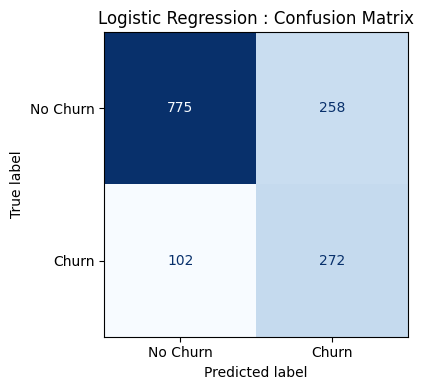

In [15]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_results = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression')


--------------------------------------------------
 Random Forest
--------------------------------------------------
AUC-ROC Score: 0.8165

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.84      1033
       Churn       0.56      0.65      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.77      1407



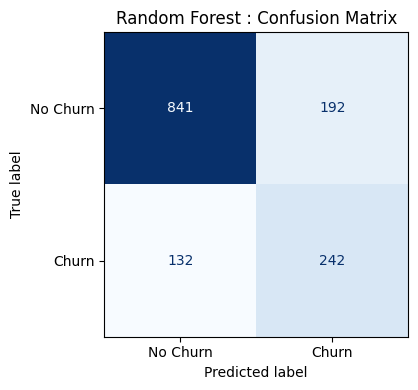

In [16]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_results = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

scale_pos_weight: 1.00 (neg=4130, pos=4130)

--------------------------------------------------
 XGBoost
--------------------------------------------------
AUC-ROC Score: 0.8271

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.76      0.82      1033
       Churn       0.52      0.71      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.78      0.75      0.76      1407



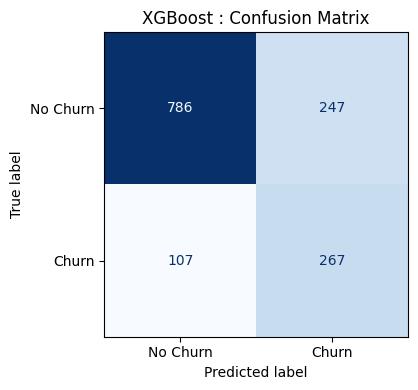

In [17]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight: {spw:.2f} (neg={neg}, pos={pos})')

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

xgb_results = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

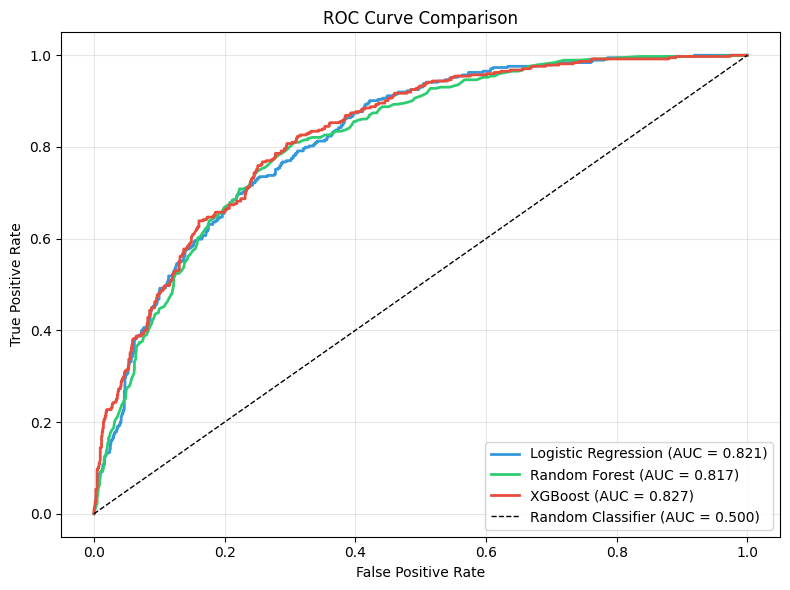

ROC curve saved.


In [18]:
# ROC Curve comparison
fig, ax = plt.subplots(figsize=(8, 6))

for result, color in zip(
    [lr_results, rf_results, xgb_results],
    ['#3498db', '#2ecc71', '#e74c3c']
):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{result['model']} (AUC = {result['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC curve saved.')

In [19]:
# Summary table
from sklearn.metrics import precision_score, recall_score, f1_score

summary = []
for result in [lr_results, rf_results, xgb_results]:
    y_pred = result['y_pred']
    summary.append({
        'Model': result['model'],
        'AUC-ROC': round(result['auc'], 4),
        'Precision (Churn)': round(precision_score(y_test, y_pred), 4),
        'Recall (Churn)': round(recall_score(y_test, y_pred), 4),
        'F1 (Churn)': round(f1_score(y_test, y_pred), 4),
    })

summary_df = pd.DataFrame(summary)
print('\nModel Comparison Summary:')
print(summary_df.to_string(index=False))


Model Comparison Summary:
              Model  AUC-ROC  Precision (Churn)  Recall (Churn)  F1 (Churn)
Logistic Regression   0.8207             0.5132          0.7273      0.6018
      Random Forest   0.8165             0.5576          0.6471      0.5990
            XGBoost   0.8271             0.5195          0.7139      0.6014


In [20]:
os.makedirs('../models', exist_ok=True)

#models saved
joblib.dump(lr_model,  '../models/logistic_regression.pkl')
joblib.dump(rf_model,  '../models/random_forest.pkl')
joblib.dump(xgb_model, '../models/xgboost.pkl')


best = max([lr_results, rf_results, xgb_results], key=lambda x: x['auc'])
best_model_map = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}
joblib.dump(best_model_map[best['model']], '../models/best_model.pkl')

print(f"Best model: {best['model']} (AUC = {best['auc']:.4f})")
print('All models saved to models/')
print(os.listdir('../models'))

Best model: XGBoost (AUC = 0.8271)
All models saved to models/
['best_model.pkl', 'logistic_regression.pkl', 'random_forest.pkl', 'xgboost.pkl']
